In [3]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar datos con indice de la columna Person ID
data = pd.read_csv('data/sleep health.csv', index_col='Person ID')
data.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
Person ID,,,,,,,,,,,,
1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


##### Preguntas que buscamos responder con este conjunto

##### Las preguntas que buscaremos responder con este conjunto de datos son las siguientes:

##### ¿Quiénes tienen peor calidad del sueño, hombres o mujeres?

##### ¿Existe una relación entre la calidad del sueño de las personas y su profesión?

##### ¿La actividad física afecta al sueño?

##### ¿Qué profesión presenta la peor calidad de sueño?

##### ¿Cuál profesión tienen a las personas con el mayor nivel de estrés y el mayor índice de masa corporal?

##### ¿En qué rango de edades se encuentran la mayor cantidad de trastornos del sueño?

##### La cantidad de pasos al día, ¿afecta la calidad del sueño? ¿al índice de masa corporal?

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374 entries, 1 to 374
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Blood Pressure           374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 38.0+ KB


In [ ]:
data.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
# Verificar los tipos de datos de cada columna
data.dtypes

Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

In [ ]:
# Seleccionar solo columnas numéricas
numeric_data=data.select_dtypes(include=['float64', 'int64'])
print(numeric_data.head()) 

           Age  Sleep Duration  Quality of Sleep  Physical Activity Level  \
Person ID                                                                   
1           27             6.1                 6                       42   
2           28             6.2                 6                       60   
3           28             6.2                 6                       60   
4           28             5.9                 4                       30   
5           28             5.9                 4                       30   

           Stress Level  Heart Rate  Daily Steps  
Person ID                                         
1                     6          77         4200  
2                     8          75        10000  
3                     8          75        10000  
4                     8          85         3000  
5                     8          85         3000  


In [ ]:
# conteo de valores faltantes
data.isnull().sum()

Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

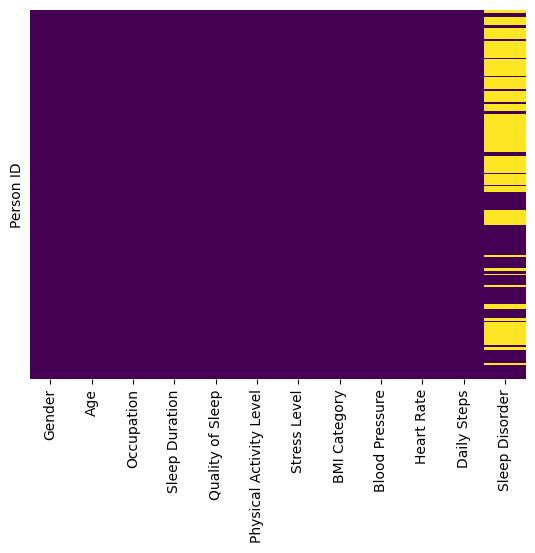

In [ ]:
# Visualizar valores faltantes
sns.heatmap(data.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.show()  

### analisis de edad

In [ ]:
# filtrar columna Gender
data['Gender'].value_counts()

Gender
Male      189
Female    185
Name: count, dtype: int64

In [ ]:
# promedio de la columna Age
data['Age'].mean()

42.18449197860963

In [ ]:
# deviacion estandar de la columna Age
data['Age'].std()

8.673133465547243

In [ ]:
# mediana de la columna Age
data['Age'].median()

43.0

In [ ]:
# Crear una nueva columna Age_Group basada en condiciones
data.loc[data['Age'] <= 40, 'Age_Group'] = 'Adult'
data.loc[data['Age'] >= 41, 'Age_Group'] = 'Older Adult'

In [ ]:
data.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Age_Group
Person ID,,,,,,,,,,,,,
1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN,Adult
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,Adult
3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN,Adult
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,Adult
5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,Adult


In [ ]:
data.tail()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Age_Group
Person ID,,,,,,,,,,,,,
370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Older Adult
371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Older Adult
372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Older Adult
373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Older Adult
374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea,Older Adult


In [ ]:
# agrupa por la columna gender y obten el mean y desv estandar de la columna Age
data.groupby('Gender')['Age'].agg(['mean', 'std']).round(2)

,mean,std
Gender,,
Female,47.41,8.09
Male,37.07,5.66


In [ ]:
# Contar la cantidad de cada valor en la columna Gender
data['Gender'].value_counts()


Gender
Male      189
Female    185
Name: count, dtype: int64

In [ ]:
# filtrar columnas gender y age
data[['Gender', 'Age']]

,Gender,Age
Person ID,,
1,Male,27
2,Male,28
3,Male,28
4,Male,28
5,Male,28
...,...,...
370,Female,59
371,Female,59
372,Female,59


In [ ]:
# Contar la frecuencia de cada grupo de edad
age_group_counts = data['Age_Group'].value_counts()

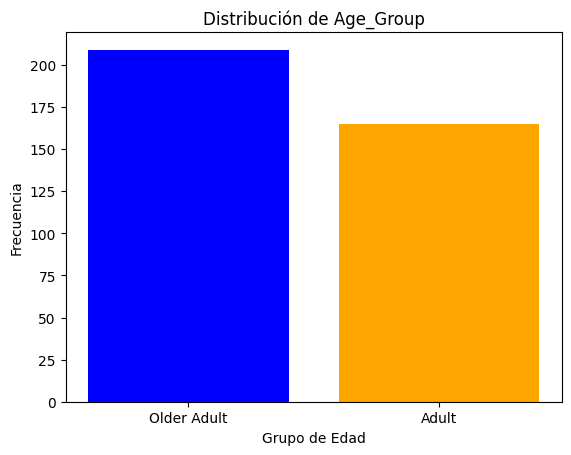

In [ ]:
# Crear el gráfico de barras age_group_counts
plt.bar(age_group_counts.index, age_group_counts.values, color=['blue', 'orange'])

# Personalizar el gráfico
plt.title('Distribución de Age_Group')
plt.xlabel('Grupo de Edad')
plt.ylabel('Frecuencia')
plt.show()  

### Analisis de ocupaciones

In [ ]:
# analiza las ocupaciones y sus frecuencias
occupation_counts = data['Occupation'].value_counts()
print(occupation_counts)

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64


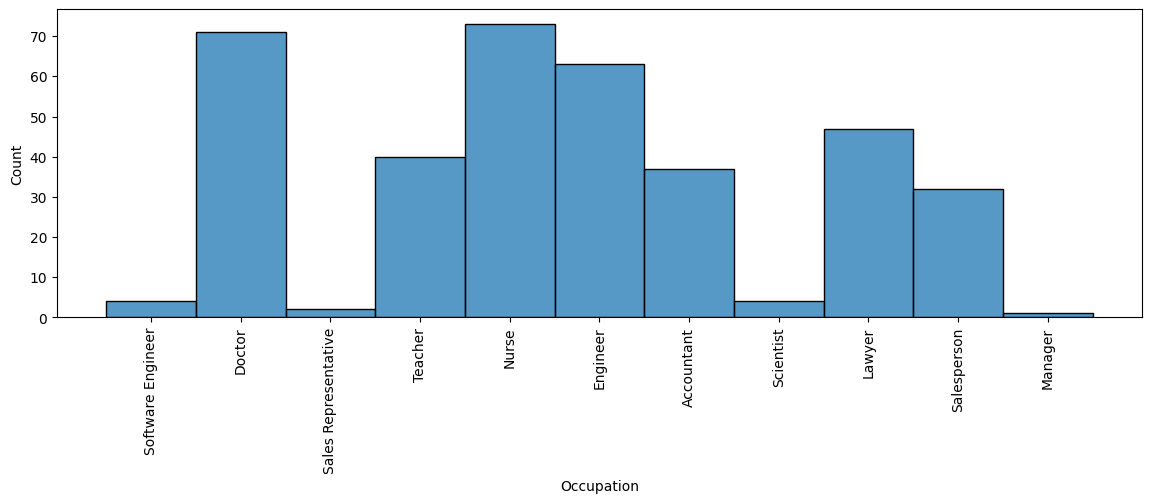

In [ ]:
# histograma de la columna ocupation gira el eje x a 90 grados
plt.figure(figsize=(14, 4))
sns.histplot(data['Occupation'], kde=False, bins=10)
plt.xticks(rotation=90)
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.show()

In [ ]:
# agrupar por la columna ocupation agrega columna gender y contar los valores
data.groupby('Occupation')['Gender'].value_counts()

Occupation            Gender
Accountant            Female    36
                      Male       1
Doctor                Male      69
                      Female     2
Engineer              Female    32
                      Male      31
Lawyer                Male      45
                      Female     2
Manager               Female     1
Nurse                 Female    73
Sales Representative  Male       2
Salesperson           Male      32
Scientist             Female     4
Software Engineer     Male       4
Teacher               Female    35
                      Male       5
Name: count, dtype: int64

In [ ]:
# obtener valor min y max de la columna sleep duration
data['Sleep Duration'].min(), data['Sleep Duration'].max()

(5.8, 8.5)

In [ ]:
# agrupar por columna gender obtener el promedio de las columna sleep duration y quality of sleep
data.groupby('Gender')[['Sleep Duration', 'Quality of Sleep']].mean().round(2)

,Sleep Duration,Quality of Sleep
Gender,,
Female,7.23,7.66
Male,7.04,6.97


In [ ]:
# agrupar por columna ocupacion obtener el promedio de las columna sleep duration y quality of sleep y ademas Ordenar por Quality of Sleep de forma descendente
occ_qua=data.groupby('Occupation')[['Sleep Duration', 'Quality of Sleep']].mean()
occ_qua.sort_values('Quality of Sleep', ascending=True).round(2)

,Sleep Duration,Quality of Sleep
Occupation,,
Sales Representative,5.90,4.00
Scientist,6.00,5.00
Salesperson,6.40,6.00
Software Engineer,6.75,6.50
Doctor,6.97,6.65
Teacher,6.69,6.98
Manager,6.90,7.00
Nurse,7.06,7.37
Accountant,7.11,7.89


In [ ]:
# obtener el indice de masa corporal en una nueva variable occ_BMI y contar los valores agrupados por ocupation
occ_bmi=data.groupby('Occupation')['BMI Category'].value_counts()
occ_bmi.sort_values()

Occupation            BMI Category 
Lawyer                Normal Weight     1
Software Engineer     Overweight        1
                      Obese             1
Manager               Overweight        1
Teacher               Obese             1
Doctor                Normal Weight     2
Lawyer                Obese             2
                      Overweight        2
Software Engineer     Normal Weight     2
Sales Representative  Obese             2
Engineer              Overweight        3
                      Normal Weight     4
Doctor                Obese             4
Scientist             Overweight        4
Accountant            Normal Weight     5
                      Overweight        6
Teacher               Normal            6
Nurse                 Normal Weight     7
Accountant            Normal           26
Salesperson           Overweight       32
Teacher               Overweight       33
Lawyer                Normal           42
Engineer              Normal           5

In [ ]:
# agrupar por ocupation y contar los valores agrupados por columna BMI Category
data['BMI Category'].value_counts()

BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

In [ ]:
occ_steps=data.groupby('Occupation')[['Daily Steps', 'Physical Activity Level', 'Sleep Duration', 'Quality of Sleep']].mean().round(2)
occ_steps.sort_values(by='Daily Steps')

,Daily Steps,Physical Activity Level,Sleep Duration,Quality of Sleep
Occupation,,,,
Sales Representative,3000.00,30.00,5.90,4.00
Scientist,5350.00,41.00,6.00,5.00
Manager,5500.00,55.00,6.90,7.00
Software Engineer,5800.00,48.00,6.75,6.50
Teacher,5957.50,45.62,6.69,6.98
Engineer,5980.95,51.86,7.99,8.41
Salesperson,6000.00,45.00,6.40,6.00
Doctor,6808.45,55.35,6.97,6.65
Accountant,6881.08,58.11,7.11,7.89


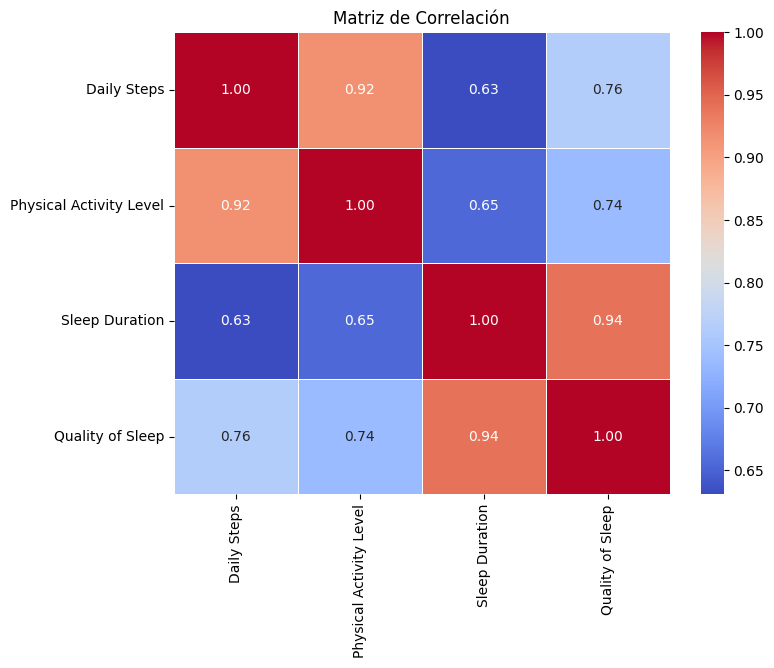

In [ ]:
# Calcular la matriz de correlación
correlation_matrix = occ_steps.corr()

# Crear el heatmap de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Personalizar el gráfico
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
import plotly.express as px

In [ ]:
# Calcular la matriz de correlación
correlation_matrix = occ_steps.corr().round(2)

# Crear el heatmap interactivo con Plotly
fig = px.imshow(
    correlation_matrix,
    text_auto=True,  # Mostrar valores en las celdas
    color_continuous_scale='Viridis_r',  # Escala de colores
    title="Matriz de Correlación",
    labels=dict(color="Correlación"),  # Etiqueta para la barra de color
)

# Personalizar el diseño
fig.update_layout(
    title_font_size=20,
    title_x=0.2,  # Centrar el título
    font=dict(size=12),
    coloraxis_colorbar=dict(
        title="Correlación",
        tickvals=[-1, -0.5, 0, 0.5, 1],  # Valores en la barra de color
        ticktext=["-1 (Negativa)", "-0.5", "0 (Nula)", "0.5", "1 (Positiva)"]
    )
)

# Mostrar el gráfico
fig.show()

In [ ]:
# Agrupar por Occupation, calcular el promedio y redondear a 2 decimales
occ_steps = data.groupby('Occupation')[['Daily Steps', 'Physical Activity Level', 'Sleep Duration', 'Quality of Sleep']].mean().round(2)

# Restablecer el índice para usar 'Occupation' como columna
occ_steps = occ_steps.reset_index()

# Crear un gráfico de radar interactivo con Plotly
fig = px.line_polar(
    occ_steps.melt(id_vars='Occupation', var_name='Metric', value_name='Value'),  # Transformar datos a formato largo
    r='Value',  # Valores en el eje radial
    theta='Metric',  # Métricas en el eje angular
    color='Occupation',  # Diferenciar por ocupación
    line_close=True,  # Cerrar las líneas del radar
    title="Comparación de métricas por ocupación (Gráfico de Radar)",
    template="plotly_dark",  # Tema oscuro para mayor impacto visual
    color_discrete_sequence=px.colors.qualitative.Set2  # Paleta de colores atractiva
)

# Personalizar el diseño
fig.update_layout(
    title_font_size=20,
    title_x=0.5,  # Centrar el título
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, occ_steps.iloc[:, 1:].max().max()]  # Ajustar el rango radial al máximo valor
        )
    ),
    legend_title="Ocupación",
    font=dict(size=12)
)

# Mostrar el gráfico
fig.show()